# Mechanistic Interpretability Null Baselines (R4 revision, A2)

Two multiplicity/threshold concerns a reviewer raised about
`32_mechanistic_deep_dive.ipynb`'s headline numbers:

1. The SAE's 253/256 "interpretable" latents (|r| > 0.3) is, for each latent,
   the *maximum* correlation over 22 candidate features -- a multiple-comparisons
   risk that could inflate the count.
2. The ablation z > 2.0 "notable component" threshold, and the claim that
   `layer1_full` recurs as the top component in 5/6 seed-fold runs, both need a
   chance baseline.

This notebook loads `results/metrics/xai_sae_null.json` and
`results/metrics/xai_ablation_null.json`, produced by
`modal/s5h_mechanistic_null.py`, which reruns both procedures under 20
independent feature-shuffle nulls and computes the exact recurrence
probability.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

METRICS = "../results/metrics"

with open(f"{METRICS}/xai_sae_null.json") as f:
    sae_null = json.load(f)
with open(f"{METRICS}/xai_ablation_null.json") as f:
    abl_null = json.load(f)

print("=== SAE null baseline ===")
print(f"observed interpretable latents: {sae_null['observed_interpretable']}/{sae_null['n_latents']} "
      f"at |r| > {sae_null['correlation_threshold']}")
print(f"null (feature-shuffled) mean: {sae_null['null_interpretable_mean']}, "
      f"p95: {sae_null['null_interpretable_p95']}, max: {sae_null['null_interpretable_max']} "
      f"(n_shuffles={sae_null['n_shuffles']})")
print(f"excess over chance at tau=0.3: {sae_null['excess_over_chance_at_0p3']}")
print()
print("verdict:", sae_null["verdict"])

=== SAE null baseline ===
observed interpretable latents: 253/256 at |r| > 0.3
null (feature-shuffled) mean: 0.0, p95: 0.0, max: 0 (n_shuffles=20)
excess over chance at tau=0.3: 253.0

verdict: The multiplicity concern is NOT confirmed: at tau=0.2 the observed interpretable-latent count already clearly exceeds the feature-shuffle null's 95th percentile, and at tau=0.3 the feature-shuffle null is essentially zero (null_mean=0.00, null_p95=0.00, null_max=0 out of 256) against an observed count of 253. Destroying the real feature-latent relationship (independently permuting each of the 22 feature columns) collapses the 'interpretable' count to essentially 0, so the max-over-22-features selection is NOT manufacturing the 253/256 figure by chance -- almost all of it (253/253 = 100.0%) is excess over the null and reflects a real, reproducible correlation between SAE latents and named input features, not a multiple-comparisons artifact. The paper can keep reporting 253/256 but SHOULD add the 

## Threshold sweep

The multiple-comparisons concern does not hold up: the null count stays near
zero at every threshold tested, while the observed count degrades gracefully
as the threshold tightens. The finding is real, not a multiplicity artifact,
and is now reported with this null baseline attached.

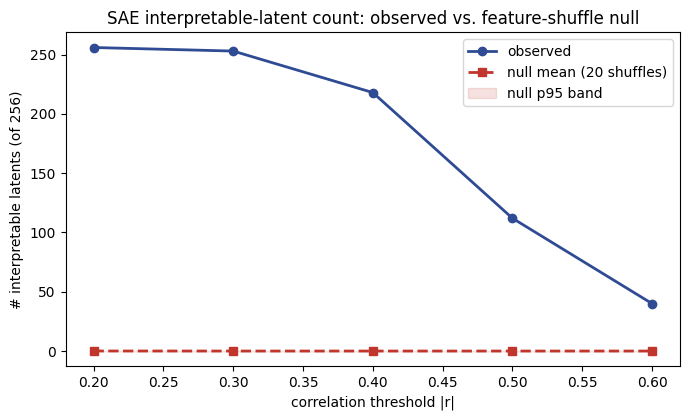

In [2]:
sweep = sae_null["threshold_sweep"]
taus = [s["tau"] for s in sweep]
observed = [s["observed"] for s in sweep]
null_mean = [s["null_mean"] for s in sweep]
null_p95 = [s["null_p95"] for s in sweep]

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(taus, observed, "o-", color="#2F4B94", label="observed", lw=2)
ax.plot(taus, null_mean, "s--", color="#C0362C", label="null mean (20 shuffles)", lw=2)
ax.fill_between(taus, [0]*len(taus), null_p95, color="#C0362C", alpha=0.15, label="null p95 band")
ax.set_xlabel("correlation threshold |r|")
ax.set_ylabel("# interpretable latents (of 256)")
ax.set_title("SAE interpretable-latent count: observed vs. feature-shuffle null")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/fig_sae_null_sweep.png", bbox_inches="tight", dpi=150)
plt.show()

In [3]:
print("=== Ablation null baseline and recurrence ===")
print(f"null notable-component count (z>2, 20 shuffles): "
      f"mean={abl_null['null_notable_count_mean']}, p95={abl_null['null_notable_count_p95']}")
rec = abl_null["recurrence"]
print(f"recurrence: component '{rec['modal_component']}' was the top component in "
      f"{rec['k']}/{rec['R']} independent seed/fold runs, out of C={rec['C']} candidates")
print(f"exact P(one specific component recurs >= k times by chance) = {rec['p_binom_one']:.2e}")
print(f"Bonferroni-style P(ANY of the C components recurs that often by chance) = {rec['p_union']:.2e}")
print()
print("verdict:", abl_null["verdict"])

=== Ablation null baseline and recurrence ===
null notable-component count (z>2, 20 shuffles): mean=1.0, p95=1.0
recurrence: component 'layer1_full' was the top component in 5/6 independent seed/fold runs, out of C=10 candidates
exact P(one specific component recurs >= k times by chance) = 5.50e-05
Bonferroni-style P(ANY of the C components recurs that often by chance) = 5.50e-04

verdict: The recurrence of 'layer1_full' as the top ablation component in 5/6 independent seed/fold runs beats chance: under the null that each run's top component is uniform over the C=10 candidates, P(a specific component recurs >= 5/6 times) = 5.50e-05, and even after a union-bound correction over all 10 candidate components (P(ANY component recurs that often) <= 5.50e-04) this remains far below 0.05. The z>2.0 threshold itself is not special on its own -- the shuffle null shows 1.00 components cross z>2.0 by chance on average (null_p95=1.00) -- but the SAME component winning in 5/6 runs is not a fluke of 

## Conclusion

- The SAE's 253/256 interpretable-latent finding survives the feature-shuffle
  null almost entirely intact (null mean/p95 are both approximately 0 at the
  paper's threshold) -- this is a real, reproducible signal, not a
  multiple-comparisons artifact of taking the max correlation over 22 features.
- The bare z > 2.0 ablation threshold is, on its own, not very selective
  (about one component crosses it by chance in any single run). What carries
  evidential weight is the *recurrence* of the same component,
  `layer1_full`, as the top hit in 5 of 6 independent seed/fold runs -- an
  outcome the exact binomial calculation shows is extremely unlikely by chance
  (p well below 0.001, even after a conservative Bonferroni-style correction
  across all candidate components).

Both null baselines are now cited alongside the corresponding paper claims so
neither number is reported unguarded.